In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# 2. Load dataset and inspect data types, nulls, duplicates
df = pd.read_csv("SuperStoreOrders.csv")

# Clean sales column (ensure float type)
df['sales'] = pd.to_numeric(df['sales'].astype(str).str.replace(',', '').str.strip(), errors='coerce')

print("=== DATASET INSPECTION ===")
print("Shape of dataset (Rows, Columns):", df.shape)
print("\n--- Column Data Types ---")
print(df.dtypes[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']])
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\n--- Duplicate Rows Count ---")
print("Duplicates:", df.duplicated().sum())
df.head(3)

=== DATASET INSPECTION ===
Shape of dataset (Rows, Columns): (51290, 21)

--- Column Data Types ---
sales              int64
quantity           int64
discount         float64
profit           float64
shipping_cost    float64
dtype: object

--- Missing Values Count ---
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

--- Duplicate Rows Count ---
Duplicates: 0


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011


In [3]:
# 3. Descriptive Statistics for all numerical columns
numerical_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']

stats_df = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Std Dev': df[numerical_cols].std(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max()
})

print("=== DESCRIPTIVE STATISTICS ===")
print(stats_df)

=== DESCRIPTIVE STATISTICS ===
                     Mean  Median   Mode     Std Dev       Min        Max
sales          246.498440   85.00  13.00  487.567175     0.000  22638.000
quantity         3.476545    3.00   2.00    2.278766     1.000     14.000
discount         0.142908    0.00   0.00    0.212280     0.000      0.850
profit          28.641740    9.24   0.00  174.424113 -6599.978   8399.976
shipping_cost   26.375915    7.79   0.86   57.296804     0.000    933.570


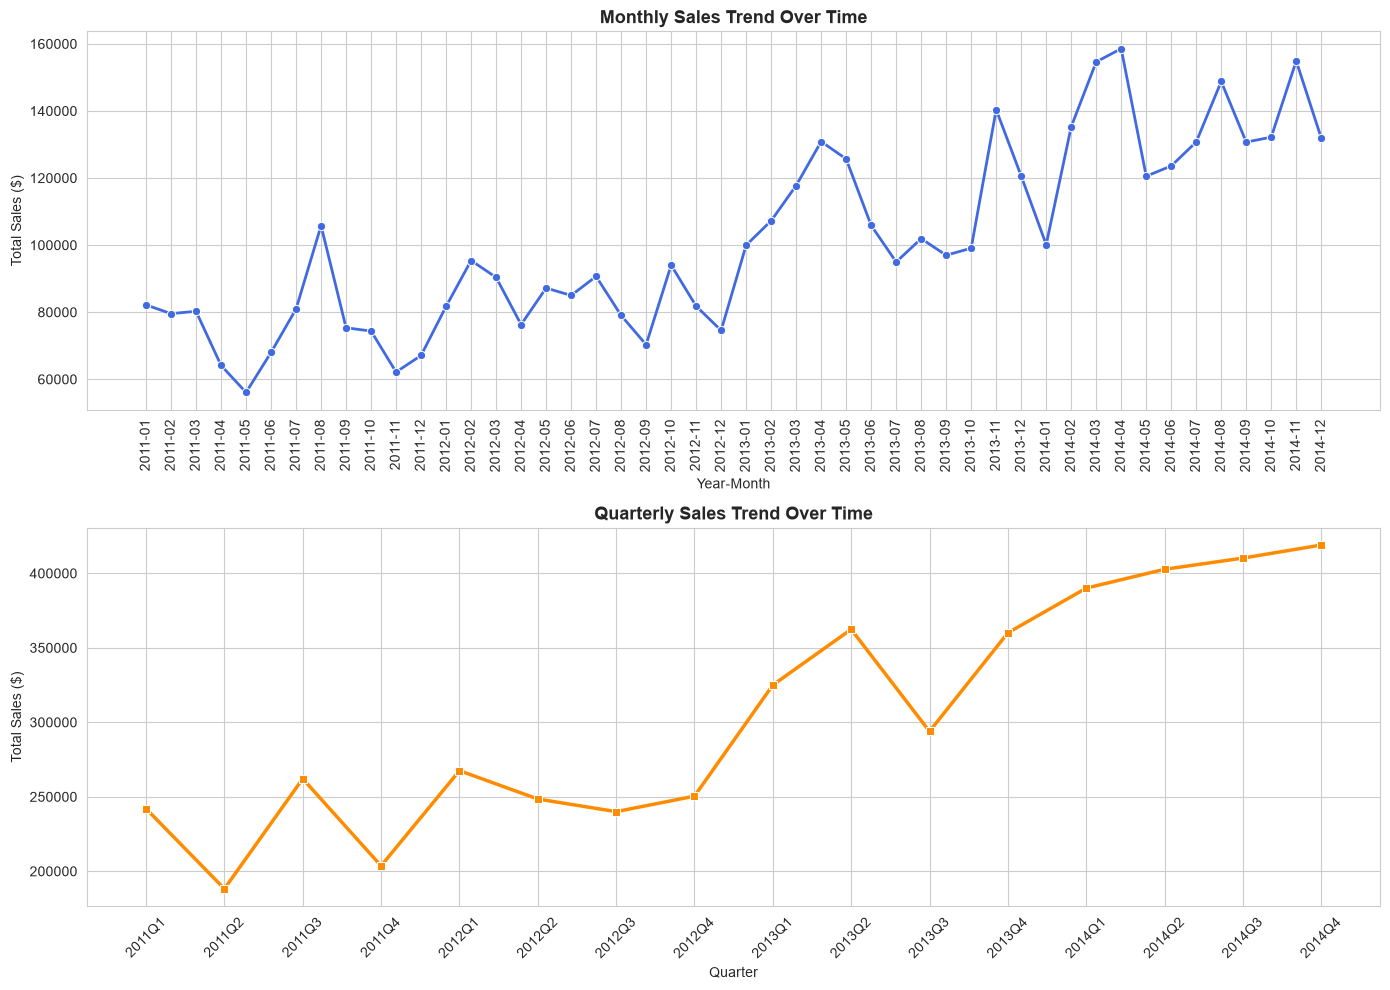

In [4]:
# 4. Convert order_date to datetime and extract time components
df["order_date"] = pd.to_datetime(df["order_date"], errors='coerce')
df["YearMonth"] = df["order_date"].dt.to_period("M").astype(str)
df["Quarter"] = df["order_date"].dt.to_period("Q").astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Monthly Sales Trend
monthly_sales = df.groupby("YearMonth")["sales"].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[0], marker='o', color='royalblue', linewidth=2)
axes[0].set_title("Monthly Sales Trend Over Time", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Year-Month")
axes[0].set_ylabel("Total Sales ($)")
axes[0].tick_params(axis='x', rotation=90)

# 2. Quarterly Sales Trend
quarterly_sales = df.groupby("Quarter")["sales"].sum()
sns.lineplot(x=quarterly_sales.index, y=quarterly_sales.values, ax=axes[1], marker='s', color='darkorange', linewidth=2.5)
axes[1].set_title("Quarterly Sales Trend Over Time", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Sales ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

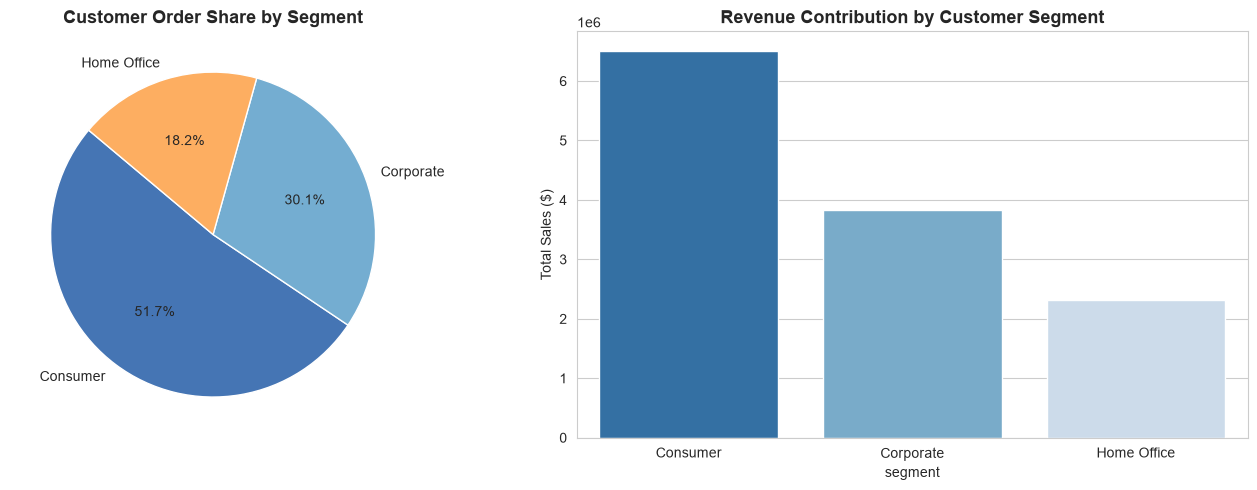

In [7]:
# 5. Customer Segment Breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer distribution by order volume (Pie chart)
segment_counts = df["segment"].value_counts()
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4575b4', '#74add1', '#fdae61'])
axes[0].set_title("Customer Order Share by Segment", fontsize=13, fontweight='bold')

# Revenue contribution by segment (Bar chart - with hue & legend=False)
segment_sales = df.groupby("segment")["sales"].sum().sort_values(ascending=False)
sns.barplot(x=segment_sales.index, y=segment_sales.values, hue=segment_sales.index, palette="Blues_r", legend=False, ax=axes[1])
axes[1].set_title("Revenue Contribution by Customer Segment", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()


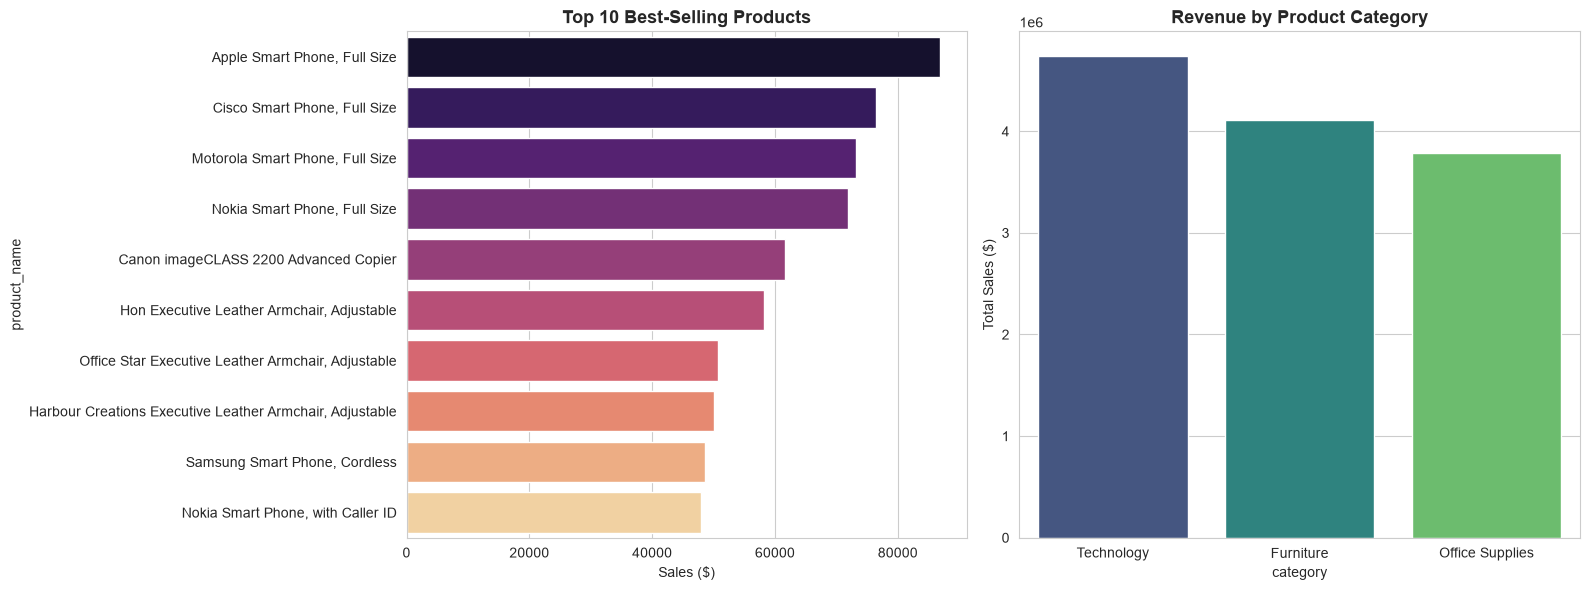

In [8]:
# 6. Product Analysis: Top 10 Best-Sellers & Category Revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Best-Selling Products
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="magma", legend=False, ax=axes[0])
axes[0].set_title("Top 10 Best-Selling Products", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sales ($)")

# Revenue by Product Category
cat_revenue = df.groupby("category")["sales"].sum().sort_values(ascending=False)
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, hue=cat_revenue.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Revenue by Product Category", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

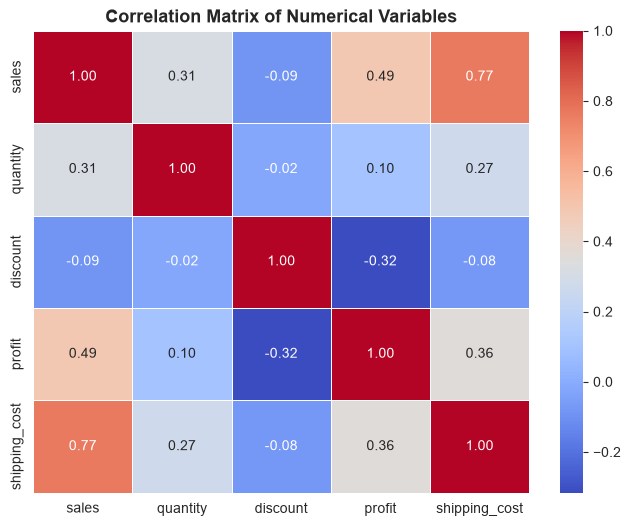

In [9]:
# 7. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables", fontsize=13, fontweight='bold')
plt.show()

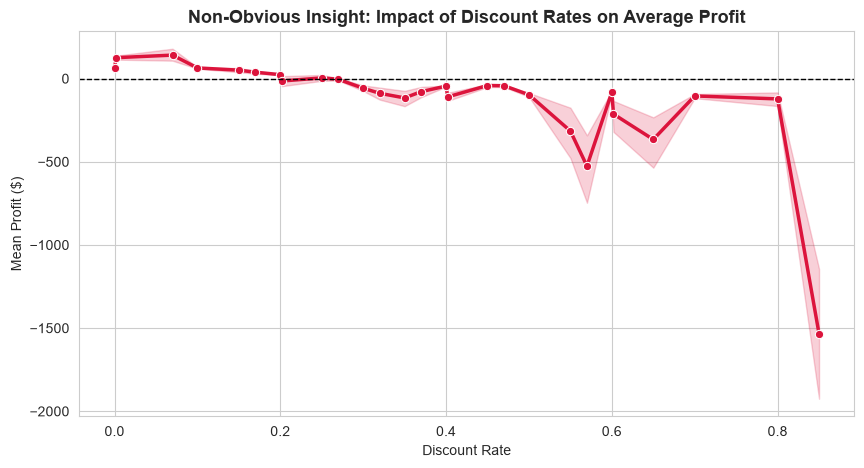

In [10]:
# 8. Impact of Discount on Profitability
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="discount", y="profit", estimator="mean", color="crimson", marker="o", linewidth=2.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Non-Obvious Insight: Impact of Discount Rates on Average Profit", fontsize=13, fontweight='bold')
plt.xlabel("Discount Rate")
plt.ylabel("Mean Profit ($)")
plt.show()

# Conclusion & Key Findings
* **Seasonality:** Peak sales consistently occur in Q4 across all calendar years.
* **Category Dominance:** Technology and Furniture lead total revenue, with Technology delivering higher net margins.
* **Discount Vulnerability:** Discounts beyond 20% severely push transactions into net operating losses.

# 3 Specific Actionable Recommendations
1. **Dynamic Discount Cap:** Enforce strict discount ceilings (max 20%) on low-margin categories to eliminate negative profitability.
2. **Q4 Inventory & Campaign Scaling:** Scale inventory and marketing spend in Q3 to fully capture high Q4 seasonal demand.
3. **B2B Loyalty Programs:** Deploy targeted volume discount programs for Corporate and Home Office segments to increase average basket sizes.